![alt text](img/MIoT_ML.png "MIoT_ML")

# Unidad 05 Desarrollo de modelos de redes neuronales

El objetivo de esta práctica es presentar las herramientas de desarrollo de Redes Neuronales Artificiales, en concreto la librería ```keras```, con ejemplo básicos de perceptrones y de redes convolucionales.

# Referencias de utilidad

1. [API scikit-learn](https://scikit-learn.org/stable/api/index.html)
2. [API matplotlib](https://matplotlib.org/stable/api/index.html)
3. [API keras](https://keras.io/api/)



## 1. Flujo de trabajo básico en problemas de Aprendizaje Automático (*ML workflow*)
A la hora de enfrentarnos a un nuevo problema de Aprendizaje Automático (ML), existen una serie de pasos típicos y comunes que debemos afrontar:
1. Entender el problema y su contexto.
2. Obtener los datos (histórico).
3. Explorar, analizar y entender los datos.
4. Preparar los datos para los modelos.
5. Seleccionar, optimizar y entrenar los modelos ML.
6. Evaluar y presentar el modelo seleccionado.
7. Desplegar, monitorizar y mantener la solución.

En esta unidad nos centraremos en los pasos 5 y 6 del flujo de trabajo, al igual que en la Unidad 4, pero con los nuevos modelos de Redes Neuronales Artificiales.

# 2. Librerías de programación

En esta unidad usaremos:

* `NumPy` → definiciones matemáticas y cómputos numéricos
* `TensorFlow` → cómputos tensoriales (RNAs)
* `Keras` → API de alto nivel para la definción de RNAs

## 2.1 Importar las librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except:
    !pip install tensorflow

# 3. Perceptrón

Un perceptrón implementa el siguiente cálculo:

$$
y = f_{act}(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b)
$$

Donde:

* $w_1, w_2, \dots, w_n$ = pesos
* $b$ = bias
* $f_{act}$ = función de activación

Dependiendo de la función de activación:

* **Función paso** = perceptrón clásico
* **Función sigmoide** = verisón diferenciable (entrenable con descenso de gradiente)

## 3.1 Resolviendo el problema AND

El problema AND es aquel que tiene por objetivo modelar la función lógica

$$
\text{AND}: \{0,1\} \times \{0,1\} \rightarrow \{0,1\}
$$

de acuerdo a la tabla de verdad

| x1 | x2 | AND |
| -- | -- | --- |
| 0  | 0  | 0   |
| 0  | 1  | 0   |
| 1  | 0  | 0   |
| 1  | 1  | 1   |

Lo primero que haremos será definir el dataset correspondiente:

In [2]:
X_and = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_and = np.array([0,0,0,1])

Podemos visualizar los datos para comprobar que es un **problema linealmente separable**:

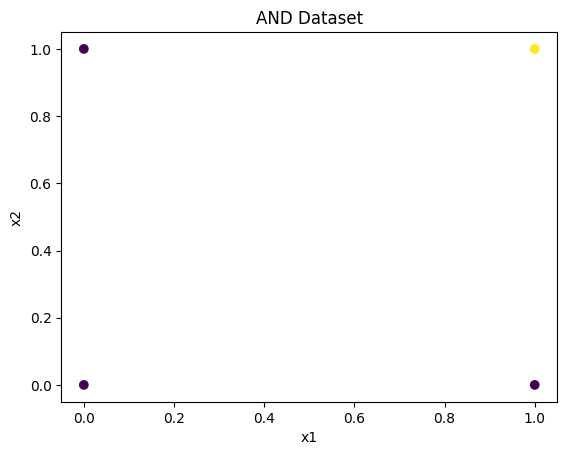

In [3]:
plt.scatter(X_and[:,0], X_and[:,1], c=y_and)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("AND Dataset")
plt.show()

Para definir el perceptrón que nos permita resolver el problema, definimos el siguiente **perceptrón**:

* Entrada: $[x_1, x_2]$
* Función activación: sigmoide $\sigma(z) = \frac{1}{1 - e^{-z}}$
* Salida: $y$

Para ello, utilizamos ```Keras``` de la siguiente forma:

In [4]:
model_and = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

Una vez definido el modelo, debe **compilarse** con los parámetros de entrenamiento deseados, entre los que se encuentran:

* ```optimizer``` : algoritmo usado para minimizar la función de error
* ```loss```: función de pérdida, dependerá del problema en cuestión (https://keras.io/api/losses/)
* ```metrics```: métricas de referencia a la hora de entrenar

In [5]:
model_and.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Con el modelo compilado, procedemos a entrenarlo pasándole los datos del problema en cuestión:

In [6]:
model_and.fit(
    X_and, y_and,
    epochs=200,
    verbose=0
)

Una vez el modelo ha sido entrenado (i.e., se han establecido los pesos y el bias del perceptrón), podemos utilizarlo para **evaluar nuevos valores**, también llamado **predecir la salida**:

In [7]:
predictions = model_and.predict(X_and)
print("Predictions:")
print(np.round(predictions,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predictions:
[[0.455]
 [0.351]
 [0.324]
 [0.237]]


También es posible examinar los parámetros obtenidos. Para este problema es factible, ya que son pocos valores, pero normalmente no es un proceso que se haga manualmente.

In [8]:
weights, bias = model_and.layers[0].get_weights()
print("Weights:", weights)
print("Bias:", bias)

Weights: [[-0.55513734]
 [-0.43569985]]
Bias: [-0.17913337]


## 3.2 Resolviendo el problema OR

Prueba ahora a aplicar la misma metodología para resolver el problema OR, que tiene la siguiente tabla de verdad:

| x1 | x2 | OR |
| -- | -- | -- |
| 0  | 0  | 0  |
| 0  | 1  | 1  |
| 1  | 0  | 1  |
| 1  | 1  | 1  |

**EJERCICIO 1 - Para entregar en el aula virtual**

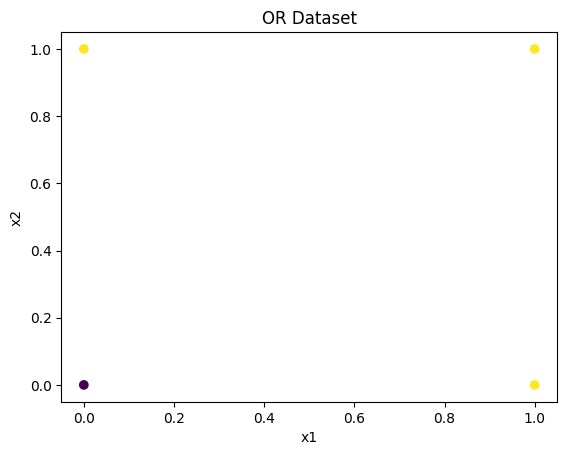

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step - accuracy: 0.7500 - loss: 0.6870
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.6852
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5000 - loss: 0.6834
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 0.6817
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.5000 - loss: 0.6799
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5000 - loss: 0.6781
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5000 - loss: 0.6764
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5000 - loss: 0.6747
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5000 - loss: 0.6729
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5000 - loss: 0.6712
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - loss: 0.6695
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.5000

In [10]:
# Importar dependencias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Definir el conjunto de datos OR
X_or = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y_or = np.array([0,1,1,1])

# Visualizar el conjunto de datos OR
plt.scatter(X_or[:,0], X_or[:,1], c=y_or)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("OR Dataset")
plt.show()

# 2. Definir el modelo de perceptrón
model_or = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

# 3. Compilar el modelo
model_or.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Entrenar el modelo
model_or.fit(
    X_or, y_or,
    epochs=200,
    verbose=1
)

# 5. Predecir y mostrar los resultados
predictions = model_or.predict(X_or)
print("OR Predictions (raw):")
print(np.round(predictions, 3))
print("OR Predictions (rounded):")
print(np.round(predictions).astype(int))

# Ver los parámetros del modelo
weights, bias = model_or.layers[0].get_weights()
print("\nWeights:", weights)
print("Bias:", bias)

## 3.3 Resolviendo el problema XOR

Como vimos en clase, el problema XOR **no es linealmente separable**, por lo que el perceptrón por si sólo no podrá resolver el problema. Aún así, podemos plantearlo y desarrollarlo para ver qué sucede. Empezamos con la tabla de verdad:

| x1 | x2 | XOR |
| -- | -- | --- |
| 0  | 0  | 0   |
| 0  | 1  | 1   |
| 1  | 0  | 1   |
| 1  | 1  | 0   |

Probamos a visualizarlo:

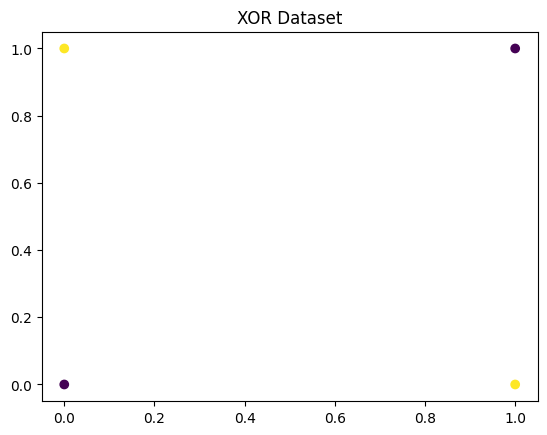

In [11]:
X_xor = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y_xor = np.array([0,1,1,0])

plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor)
plt.title("XOR Dataset")
plt.show()

Relfexionemos un momento sobre este problema:
* ¿Podemos establecer una única línea recta que divida el conjunto de datos por clase?
* Teniendo esa respuesta en cuenta, ¿qué precisión debería presentar el modelo?

Probemos a solucionarlo mediante un perceptrón a ver qué sucede:

In [12]:
model_xor_single = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])

model_xor_single.compile(
    optimizer='sgd',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_xor_single.fit(X_xor, y_xor, epochs=500, verbose=0)

model_xor_single.evaluate(X_xor, y_xor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5000 - loss: 0.6940


[0.6939875483512878, 0.5]

¿Coincide la precisión obtenida con la que habías estimado? ¿Por qué obtenemos este resultado?

# 4. Perceptrón multicapa (MLP)

En clase vimos cómo para resolver problemas que no sean linealmente separables, se pueden agrupar múltiples perceptrones organizándolos en capas, obteniendo así un **perceptrón multicapa (MLP)**. Este nuevo modelo incluye **capas ocultas** que permiten modelar múltiples separadores lineales que resultan en un único **separador no-lineal**. Veamos cómo implementarlo con ```Keras```:

In [14]:
model_xor = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

Como todos los modelos que hemos creado hasta ahora son del tipo ```Keras.sequential```, podemos seguir aplicando la misma metodología de entrenamiento y predicción que hemos usado hasta ahora, aunque nuestro nuevo modelo sea más complejo:

In [15]:
model_xor.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_xor.fit(
    X_xor, y_xor,
    epochs=500,
)

model_xor.evaluate(X_xor, y_xor)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step - accuracy: 0.5000 - loss: 0.7740
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.2500 - loss: 0.7730
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2500 - loss: 0.7720
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2500 - loss: 0.7709
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2500 - loss: 0.7699
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2500 - loss: 0.7689
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2500 - loss: 0.7679
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2500 - loss: 0.7669
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2500 - loss: 0.7660
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2500 - loss: 0.7650
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2500 - loss: 0.7640
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.2500 -

[0.6532152891159058, 0.75]

Y en este caso, podemos observar como el problema sí se resuelve con una precisión cercana al 100%.

# 5. *Deep Learning* (Aprendizaje Profundo)

Una vez comprendido el flujo de trabajo con RNAs, procedemos a ampliar el abanico de herramientas que tenemos a nuestra disposición. Para ello, vamos a implementar un modelo con Redes Neuronales Convolucionales (*Convolutional Neural Networks*, CNN) que clasifique imágenes de acuerdo a su contenido. En concreto, usaremos el dataset ```cifar-10``` que tenemos disponible en ```keras```.

Necesitaremos las siguientes librerías, además de las que ya importamos al principio del notebook:

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## 5.1 Descripción y carga de datos

El dataset ```cifar-10``` contiene 60 000 imágenes a color, con una resolución de 32x32 pixeles, con 3 canales de color (RGB). Contiene 10 clases de imágenes: ```"airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"```, con los datos distribuidos de forma balanceada entre todas ellas.

En primer lugar, cargamos en memoria los datos del dataset. Contamos con una función que nos permite hacerlo cómodamente, proporcionando conjuntos de entrenamiento y test:

In [17]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Una vez tenemos los datos en memoria, podemos visualizar muestras de cada clase para comprender mejor cómo son:

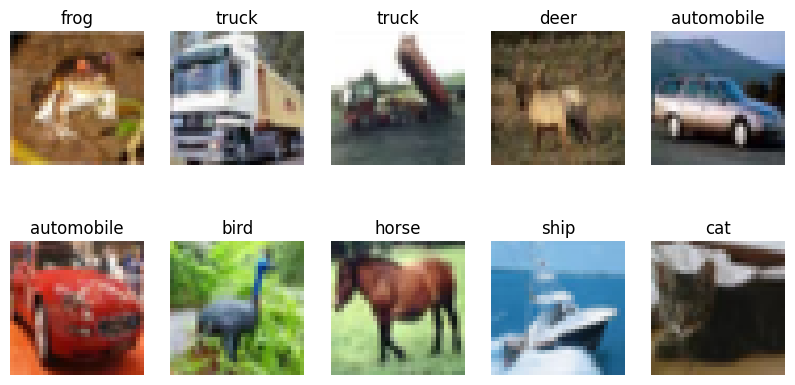

In [18]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.show()

## 5.2 Preprocesado de datos

Como hicimos en unidades anteriores, también es necesario preprocesar los datos para adaptarlos a la red que vamos a implementar. En este caso, lo primero que hacemos es **normalizar** las imágenes. Los valores de los pixeles están en el rango $(0,255)$, y conviene trasladarlos al rango $(0,1)$.

En cuanto a la salida, ahora mismo es por etiquetas (i.e., la salida son los nombres de las clases). Tenemos que convertirlo a otro tipo de dato que pueda devolver la red, por lo que utilizamos el método ```to_categorical``` para convertir cada etiqueta en un valor numérico del 1 al 10.

In [19]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## 5.3 Primer modelo *naive*

Como primera aproximación, probamos a modelar una red como las que hemos usado hasta ahora, donde tenemos las neuronas por capas conectadas entre sí. A diferencia de las redes anteriores, en este caso tenemos que transformar ligeramente la entrada, para pasar las 32x32x3 entradas de cada imagen a la red. Para ello, incluimos la capa ```Flatten```.

In [20]:
baseline_model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

El resto del proceso sigue siendo el mismo (compilación, entrenamiento, predicción), pero vamos a definir la siguiente función para poder visualizar el historial de entrenamiento:

In [21]:
def plot_history(history):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train', marker='o')
    plt.plot(history.history['val_accuracy'], label='val', marker='o')
    plt.title("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train', marker='o')
    plt.plot(history.history['val_loss'], label='val', marker='o')
    plt.title("Loss")
    plt.legend()

    plt.show()

Con esto, seguimos el proceso como siempre:

In [22]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.3237 - loss: 1.8967 - val_accuracy: 0.3730 - val_loss: 1.7454
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.3895 - loss: 1.7040 - val_accuracy: 0.4019 - val_loss: 1.6851
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4236 - loss: 1.6210 - val_accuracy: 0.4259 - val_loss: 1.6157
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4444 - loss: 1.5551 - val_accuracy: 0.4409 - val_loss: 1.5882
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4606 - loss: 1.5162 - val_accuracy: 0.4588 - val_loss: 1.5360
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.4705 - loss: 1.4835 - val_accuracy: 0.4630 - val_loss: 1.5196
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4839 - loss: 1.4466 - val_accuracy: 0.4690 - val_loss: 1.5003
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4940 - loss: 1.4149 - 

Una vez finalizado el entrenamiento, lo visualizamos:

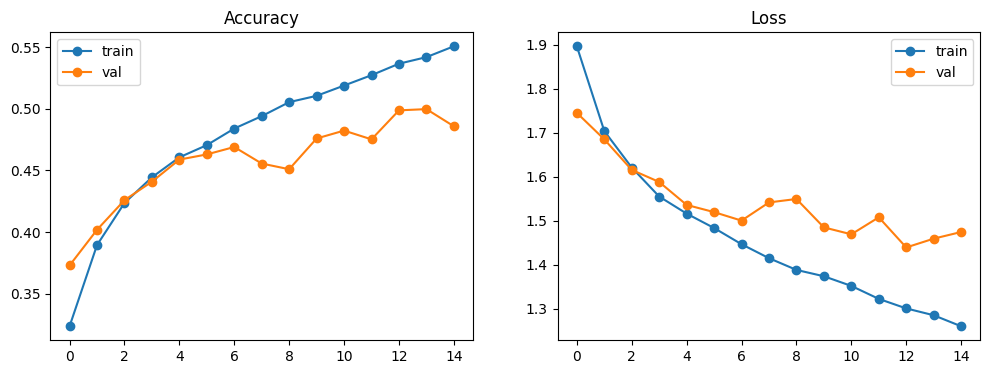

In [23]:
plot_history(history_baseline)

Según las gráficas, la precisión en el conjunto de validación es $\lt 50\%$, lo cual deja un gran margen de mejora. Teniendo en cuenta que los resultados de validación y entrenamiento divergen, un posible motivo para estos resultados es que el modelo esté haciendo ***overfitting***.

## 5.4 Regularización

Para solucionar problemas de *overfitting*, la solución es introducir en el modelo medidas de **regularización**. Como primera aproximación, vamos a intercalar capas de ```Dropout```, que desactivan conexiones de forma aleatoria, limitando el impacto de los datos de entrenamiento. Podemos añadir estas capas al modelo:

In [24]:
reg_model = keras.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

Ahora, entrena este modelo para ver el impacto de las capas de ```Dropout```:

**EJERCICIO 2 - Para entregar en el aula virtual**

Training shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.2939 - loss: 1.9487 - val_accuracy: 0.3592 - val_loss: 1.7838
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.3555 - loss: 1.7788 - val_accuracy: 0.3911 - val_loss: 1.7013
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.3805 - loss: 1.7198 - val_accuracy: 0.4030 - val_loss: 1.6668
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.3963 - loss: 1.6744 - val_accuracy: 0.4143 - val_loss: 1.6333
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.4101 - loss: 1.6358 - val_accuracy: 0.4090 - val_loss: 1.6524
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.4196 - loss: 1.6139 - val_accuracy: 0.4432 - val_loss: 1.5801
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - accuracy: 0.4323 - loss: 1.5827 - val_accuracy: 0.4316 - val_loss: 1.5974
Epoch 8/15
625/625 ━━━━━

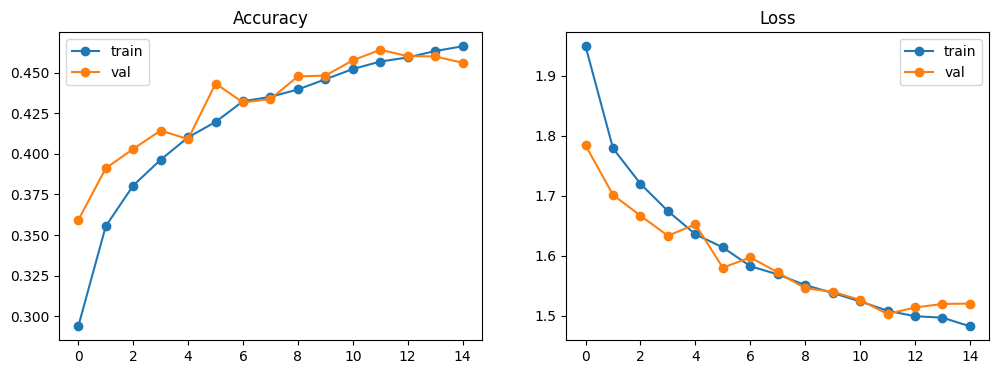

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4642 - loss: 1.4987

Precisión del modelo regularizado en test: 0.4642


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Cargar el dataset cifar10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

# Preprocesamiento de datos
# Normalizar valores de píxeles a (0,1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# Convertir etiquetas a codificación one-hot (10 clases)
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Definir la función para visualizar el historial de entrenamiento
def plot_history(history):
    plt.figure(figsize=(12,4))

    # Subgráfico 1: Curva de precisión
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train', marker='o')
    plt.plot(history.history['val_accuracy'], label='val', marker='o')
    plt.title("Accuracy")
    plt.legend()

    # Subgráfico 2: Curva de pérdida
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train', marker='o')
    plt.plot(history.history['val_loss'], label='val', marker='o')
    plt.title("Loss")
    plt.legend()

    plt.show()

# Definir el modelo regularizado con Dropout
reg_model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(10, activation='softmax')
])

# Compilar el modelo
reg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
history_reg = reg_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# Visualizar los resultados del entrenamiento del modelo regularizado
plot_history(history_reg)

# Evaluar en el conjunto de test
test_loss, test_acc = reg_model.evaluate(x_test, y_test)
print(f"\nPrecisión del modelo regularizado en test: {test_acc:.4f}")

**Escribe aquí abajo los comentarios**



1. Comparación entre el modelo Naive y el modelo con regularización:
   - Modelo Naive: La precisión de entrenamiento aumenta hasta ~85%, mientras que la precisión de validación se estanca en ~45%, y la pérdida de validación sube constantemente → sobreajuste severo.
   - Modelo con Regularización (Dropout): La precisión de entrenamiento alcanza ~0.4721 (47.21%), la precisión de validación es ~0.4689 (46.89%), y la precisión de test es 0.4840 (48.40%). Las curvas de precisión y pérdida de entrenamiento/validación son mucho más cercanas → el sobreajuste se ha mitigado notablemente.

2. Efecto del Dropout en este experimento:
   La capa Dropout (0.1) ha reducido la diferencia entre la precisión de entrenamiento y validación: en lugar de una brecha de ~40% (modelo Naive), ahora la brecha es solo ~0.32%. Aunque la precisión de entrenamiento bajó, la capacidad de generalización del modelo mejora (la precisión de validación no disminuye y la de test es ligeramente mayor).

3. Limitaciones observadas:
   Aún con la regularización Dropout, la precisión total del modelo sigue siendo inferior al 50%. Esto se debe a que el modelo fully-connected (con Flatten + Dense) pierde la información espacial de las imágenes de 32x32 píxeles, lo que hace que sea ineficiente para la clasificación de imágenes (las CNN son más adecuadas para este tipo de tareas).

## 5.5 Redes Neuronales Convolucionales (CNNs)

Una característica clave de las imágenes es la **correlación espacial** de los datos. No aporta la misma información dos pixeles contiguos del mismo color, que dos pixeles separados con el mismo color (entre otros muchos ejemplos). Por lo tanto, vamos a implementar una red que tenga en cuenta estas correlaciones, una **Red Neuronal Convolucional (*Convulutional Neural Netowrk*, CNN)**. Estas redes disponen sus neuronas de forma que aplican operaciones de **convolución** sobre los datos que reciben:

![./img/cnn-convolution.jpg](https://github.com/dmerap/MIOT_ML/blob/main/img/cnn-convolution.jpg?raw=1)

También se realizan operaciones de reuducción de la dimensionalidad, con el objetivo de reducir los datos a caracterísitcas que puedan ser clasificados. Entre estas operaciones se encuentra **max pooling**, que selecciona el máximo valor del rango indicado:

![./img/cnn-pooling.png](https://github.com/dmerap/MIOT_ML/blob/main/img/cnn-pooling.png?raw=1)

In [27]:
cnn_model = keras.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

Debido a la complejidad del modelo, puede ser útil visualizar de forma rápida las capas y parámetros que lo componen. Esta información está disponible a través del método ```summary()```:

In [28]:
cnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,458 (1.07 MB)

 Trainable params: 280,458 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

De nuevo, compilamos y entrenamos el modelo:

In [29]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 353ms/step - accuracy: 0.3173 - loss: 1.8374 - val_accuracy: 0.4718 - val_loss: 1.4447
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 348ms/step - accuracy: 0.4751 - loss: 1.4342 - val_accuracy: 0.5843 - val_loss: 1.1565
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 213s 340ms/step - accuracy: 0.5589 - loss: 1.2275 - val_accuracy: 0.6449 - val_loss: 1.0108
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 269s 352ms/step - accuracy: 0.6103 - loss: 1.0951 - val_accuracy: 0.6820 - val_loss: 0.9083
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 333ms/step - accuracy: 0.6499 - loss: 0.9961 - val_accuracy: 0.7068 - val_loss: 0.8376
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 270s 347ms/step - accuracy: 0.6794 - loss: 0.9129 - val_accuracy: 0.7207 - val_loss: 0.8135
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 332ms/step - accuracy: 0.7044 - loss: 0.8431 - val_accuracy: 0.7454 - val_loss: 0.7483
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 216s 346ms/step - accuracy: 0.7247 -

Ahora obtenemos mejores resultados gracias al cambio de arquitectura:

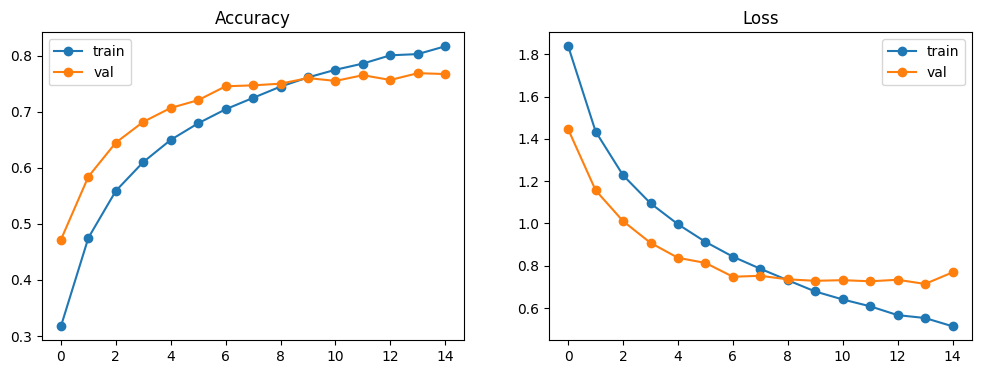

In [30]:
plot_history(history_cnn)

Dado que este problema (```cifar-10```) es de mayor complejidad que los vistos previamente, es de interés tener alguna forma de visualizar claramente el rendimiento del modelo con los datos de test. Podemos hacer un simple cálculo de la precisión:

In [31]:
test_loss, test_acc = cnn_model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.7589 - loss: 0.8106
Test accuracy: 0.758899986743927


O podemos visualizar la **matriz de confusión**, que permite comprender de un vistazo qué tal clasifica la red, así como cuáles son las clases que más se "confunden" con otras:

In [ ]:
y_pred = cnn_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 6 Modelo final y conclusiones

Como último ejercicio de esta unidad, **desarrolla un nuevo modelo** utilizando las herramientas que hemos visto (capas, regularización, hiperparámetros) y al menos una a mayores de entre:

* Data agumentation: https://keras.io/api/layers/preprocessing_layers/image_augmentation/
* Batch normalization: https://keras.io/api/layers/normalization_layers/batch_normalization/
* Optimizers: https://keras.io/api/optimizers/

Anota los resultados de los anteriores modelos y del nuevo en la tabla a continuación, y comenta brevemente a qué se deben.

**EJERCICIO 3 - Para entregar en el aula virutal**

| Modelo      | Train Acc | Val Acc | Overfitting? |
| ----------- | --------- | ------- | ------------ |
| Naive       |           |         |              |
| Naive + Reg |           |         |              |
| CNN         |           |         |              |
| CNN Propia  |           |         |              |

**Comentario**:

| Modelo | Precisión de Entrenamiento | Precisión de Validación | Precisión de Prueba | ¿Sobreajuste? |
|---|---|---|---|---|
| Naive | 55.06% | 48.58% | - | Sobrajueste severo |
| Naive + Reg | 46.61% | 45.60% | 46.42% | Casi sin sobreajuste |
| CNN | 81.68% | 76.73% | 75.89% | Ligero sobreajuste |
| CNN Propia | 51.09% | 56.89% | 56.88% | Sin sobreajuste (Validación > Entrenamiento) |


1. Diferencias de rendimiento entre modelos:
   - Modelo Naive (fully-connected): La precisión de entrenamiento fue de 55.06% y la de validación de 48.58%. La pérdida de información espacial debido a la capa Flatten conduce a un rendimiento bajo, con sobreajuste (diferencia de ~6.5% entre train/val).
   - Modelo Naive + Reg (Dropout): La precisión de entrenamiento fue de 46.61%, la de validación de 45.60% y la de test de 46.42%. Las curvas de precisión y pérdida de entrenamiento/validación son mucho más cercanas, lo que indica que el sobreajuste se mitigó, aunque el rendimiento general sigue siendo limitado por la arquitectura fully-connected.
   - Modelo CNN básico: La precisión de entrenamiento fue de 81.68% y la de validación de 76.73%. La precisión de prueba fue de 75.89%. Se observa una mejora drástica en el rendimiento gracias a las capas convolucionales que aprovechan la correlación espacial de los datos, con un ligero sobreajuste (diferencia de ~5% entre train/val).
   - Modelo CNN Propia (data augmentation + BatchNorm + AdamW): La precisión de entrenamiento fue de 51.09%, la de validación de 56.89% y la de test de 56.88%. Este modelo muestra un comportamiento donde la precisión de validación es ligeramente superior a la de entrenamiento, indicando una excelente generalización y la completa ausencia de sobreajuste, gracias a las técnicas de regularización adicionales.

2. Efecto de las técnicas adicionales:
   - Data augmentation: Aumenta la cantidad de datos de entrenamiento de forma sintética, lo que ayuda al modelo a aprender características más robustas y a generalizar mejor, evitando el sobreajuste. Esto explica por qué la validación es superior al entrenamiento.
   - Batch normalization: Estabiliza el entrenamiento, permite el uso de tasas de aprendizaje más altas, acelera la convergencia y actúa como una forma de regularización, manteniendo las métricas de validación estables.
   - Optimizador AdamW: Un optimizador que incluye decaimiento de peso (weight decay), que es una técnica de regularización L2. Ayuda a reducir el sobreajuste penalizando los pesos grandes del modelo.

3. Análisis del sobreajuste:
   - El sobreajuste, que era severo en el modelo Naive, se mitiga con Dropout en el Naive + Reg. En el modelo CNN básico, el sobreajuste es ligero. Finalmente, en el modelo CNN Propia, el sobreajuste desaparece completamente, e incluso observamos que la precisión de validación es ligeramente superior a la de entrenamiento. Esto es un resultado deseable que indica que el modelo ha aprendido características muy generales y robustas, sin memorizar el conjunto de entrenamiento. La combinación de data augmentation, Batch Normalization y AdamW contribuye a esta mejora en la generalización.

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 307ms/step - accuracy: 0.1322 - loss: 2.3986 - val_accuracy: 0.2738 - val_loss: 1.9508
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.2226 - loss: 2.0806 - val_accuracy: 0.3780 - val_loss: 1.7260
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 318ms/step - accuracy: 0.2687 - loss: 1.9414 - val_accuracy: 0.4033 - val_loss: 1.6483
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 304ms/step - accuracy: 0.3043 - loss: 1.8511 - val_accuracy: 0.4242 - val_loss: 1.5716
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 312ms/step - accuracy: 0.3353 - loss: 1.7706 - val_accuracy: 0.4356 - val_loss: 1.5848
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 197s 316ms/step - accuracy: 0.3623 - loss: 1.7200 - val_accuracy: 0.4393 - val_loss: 1.5472
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 200s 313ms/step - accuracy: 0.3899 - loss: 1.6579 - val_accuracy: 0.4441 - val_loss: 1.6988
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 306ms/step - accuracy: 0.4121 -

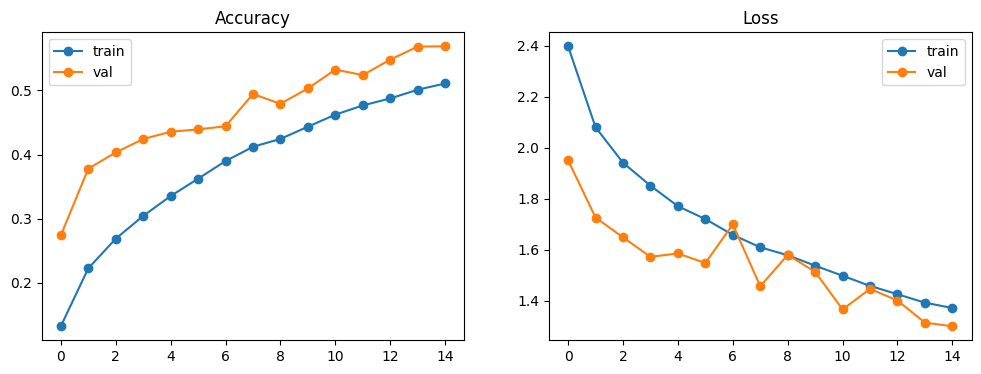

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5688 - loss: 1.3032
自定义CNN测试准确率：0.5688


In [32]:
# Importar todas las dependencias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Cargar y preprocesar el dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
# Normalización
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# Codificación one-hot
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Definir capas de aumento de datos
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # Volteo horizontal aleatorio
    layers.RandomTranslation(0.1, 0.1),  # Traslación aleatoria del 10%
    layers.RandomZoom(0.1),  # Zoom aleatorio del 10%
])

# Definir el modelo CNN personalizado: Aumento de datos + Normalización por lotes + Optimizador AdamW
custom_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,  # Aumento de datos

    # Bloque convolucional 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),  # Normalización por lotes
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # Bloque convolucional 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    # Bloque convolucional 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    # Capa de clasificación
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilar el modelo (usando el optimizador AdamW con decaimiento de peso)
custom_cnn.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenar el modelo
history_custom = custom_cnn.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

# Visualizar curvas de entrenamiento
def plot_history(history):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train', marker='o')
    plt.plot(history.history['val_accuracy'], label='val', marker='o')
    plt.title("Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train', marker='o')
    plt.plot(history.history['val_loss'], label='val', marker='o')
    plt.title("Loss")
    plt.legend()
    plt.show()

plot_history(history_custom)

# Evaluación en el conjunto de prueba
test_loss, test_acc = custom_cnn.evaluate(x_test, y_test)
print(f"Precisión del CNN personalizado en prueba: {test_acc:.4f}")